In [1]:
# Load our libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt

2026-02-04 14:18:38.857428: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-04 14:18:38.887677: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Formulate / Outline the problem

We'll now shift focus to another dataset and another problem. Weather prediction, in specific, **predict sunshine hours for Basel**.

Sunshine hours is a numeric variable, and therefore our problem is no longer classification (into categories) but rather **regression** (for numbers / continuous values).

## 2. Identify inputs and outputs

In [2]:
# Load the data
data = pd.read_csv("https://zenodo.org/record/5071376/files/weather_prediction_dataset_light.csv?download=1")

In [3]:
# Print some info for our data
print("Number of (rows, columns): ", data.shape)
print("Column names: ", data.columns)

Number of (rows, columns):  (3654, 91)
Column names:  Index(['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity',
       'BASEL_pressure', 'BASEL_global_radiation', 'BASEL_precipitation',
       'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max',
       'DE_BILT_cloud_cover', 'DE_BILT_humidity', 'DE_BILT_pressure',
       'DE_BILT_global_radiation', 'DE_BILT_precipitation', 'DE_BILT_sunshine',
       'DE_BILT_temp_mean', 'DE_BILT_temp_min', 'DE_BILT_temp_max',
       'DRESDEN_cloud_cover', 'DRESDEN_humidity', 'DRESDEN_global_radiation',
       'DRESDEN_precipitation', 'DRESDEN_sunshine', 'DRESDEN_temp_mean',
       'DRESDEN_temp_min', 'DRESDEN_temp_max', 'DUSSELDORF_cloud_cover',
       'DUSSELDORF_humidity', 'DUSSELDORF_pressure',
       'DUSSELDORF_global_radiation', 'DUSSELDORF_precipitation',
       'DUSSELDORF_sunshine', 'DUSSELDORF_temp_mean', 'DUSSELDORF_temp_min',
       'DUSSELDORF_temp_max', 'HEATHROW_cloud_cover', 'HEATHROW_humidity',
       'HEATHROW

In [4]:
# Look at first five rows
data.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,TOURS_humidity,TOURS_pressure,TOURS_global_radiation,TOURS_precipitation,TOURS_temp_mean,TOURS_temp_min,TOURS_temp_max
0,20000101,1,8,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,...,-15.2,-17.0,-13.4,0.97,1.0275,0.25,0.04,8.5,7.2,9.8
1,20000102,1,8,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,...,-13.7,-15.0,-12.3,0.99,1.0293,0.17,0.16,7.9,6.6,9.2
2,20000103,1,5,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,...,-9.2,-12.5,-5.8,0.91,1.0267,0.27,0.00,8.1,6.6,9.6
3,20000104,1,7,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,...,-5.6,-7.0,-4.2,0.95,1.0222,0.11,0.44,8.6,6.4,10.8
4,20000105,1,5,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,...,-7.6,-9.4,-5.8,0.95,1.0209,0.39,0.04,8.0,6.4,9.5


In [5]:
# See what data types we have and if the dataset is complete
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3654 entries, 0 to 3653
Data columns (total 91 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   DATE                         3654 non-null   int64  
 1   MONTH                        3654 non-null   int64  
 2   BASEL_cloud_cover            3654 non-null   int64  
 3   BASEL_humidity               3654 non-null   float64
 4   BASEL_pressure               3654 non-null   float64
 5   BASEL_global_radiation       3654 non-null   float64
 6   BASEL_precipitation          3654 non-null   float64
 7   BASEL_sunshine               3654 non-null   float64
 8   BASEL_temp_mean              3654 non-null   float64
 9   BASEL_temp_min               3654 non-null   float64
 10  BASEL_temp_max               3654 non-null   float64
 11  DE_BILT_cloud_cover          3654 non-null   int64  
 12  DE_BILT_humidity             3654 non-null   float64
 13  DE_BILT_pressure             

Some things we can conclude from our dataset:
- 91 columns: date (yyymmdd format), month (numeric), and weather variables for 11 different cities in Europe.
- 3654 rows, meaning 3654 days of collected data (or 10 years).
- All variables/features are numeric
- It doesn't seem like we have empty/null values
- We want to predict `BASEL_sunshine` on day `i+1` based on all other variables on day `i`.

## 3. Prepare data

As usual, our data preparation requires: data cleaning, defining output/target/y and inputs/features/x, and splitting intro train and test sets

In [6]:
## First, build the models as we only had information for 3 years
nr_rows = 365*3 # 3 years

# Prepare features. We won't be using DATE or MONTH
X_data = data.loc[0:nr_rows]
X_data = X_data.drop(columns=['DATE', 'MONTH'])

# Prepare target, knowing that our target is BASEL_sunshine for day i+1
y_data = data.loc[1:(nr_rows + 1), "BASEL_sunshine"]

### Data Splitting Strategy: Train, Validation, and Test

To build a model that actually works in the real world, we are moving from a 2-way split to a **3-way partition**.

Why the change?
Previously, we used the `test` set for evaluation. However, every time we "tweak" the model to get a better score on that test set, we are accidentally leaking information. The model is no longer being tested on "unseen" data because the developer has shaped the model to fit that specific data.

The Three Partitions

* **Train Set**: The "Textbook." This is the data the model looks at to learn patterns and adjust its weights.
* **Validation Set**: The "Practice Exam." We use this during training to compare different architectures and tune hyperparameters. The model doesn't learn from this data directly, but we use its results to decide which model version is best.
* **Test Set**: The "Final Exam." This is a locked vault. It is used **only once** at the very end to provide an unbiased measure of how the final model will perform in the real world.

In short:
| Split | Purpose | Used for Training? | Influences Model Design? |
| :--- | :--- | :--- | :--- |
| **Train** | Learning weights | Yes | Yes |
| **Validation** | Tuning & Selection | No | Indirectly (via the developer) |
| **Test** | Final Evaluation | No | No |

In [7]:
# Split intro train and holdout (which will later be split into validation and test)
# A conventional 70% of the data for training
X_train, X_holdout, y_train, y_holdout = train_test_split(X_data, y_data, test_size=0.3, random_state=0)

# Using our holdout, split evenly (15/15%) into validation and test
X_val, X_test, y_val, y_test = train_test_split(X_holdout, y_holdout, test_size=0.5, random_state=0)

## 4. Build an architecture from scratch, or choose a pretrained model

We'll write a reusable function for an architecture with two hidden layers, but a variable number of: 1) inputs (features), 2) neurons in each layer.

Another key difference is that, as we now have a regression problem, we only have 1 output neuron.

In [8]:
## Fill-in the blanks

# Set our random seed
keras.utils.set_random_seed(2)

# Define our function for creating our NN model with varying hyperparameters

def create_nn(input_shape, n_neurons):
    # Input layer
    inputs = keras.Input(shape=input_shape)

    # Dense layers
    layers_dense = keras.layers.Dense(n_neurons[0], 'relu')(inputs)
    layers_dense = keras.layers.Dense(n_neurons[1], 'relu')(layers_dense)

    # Output layer
    outputs = keras.layers.Dense(1)(layers_dense)

    return keras.Model(inputs=inputs, outputs=outputs, name=f"weather_model_{n_neurons[0]}_{n_neurons[1]}")

In [9]:
# Our starting model
model_100_50 = create_nn(input_shape = (X_data.shape[1],), n_neurons = [100, 50])

In [10]:
model_100_50.summary()

Model: "weather_model_100_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 89)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │         9,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,101 (55.08 KB)

 Trainable params: 14,101 (55.08 KB)

 Non-trainable params: 0 (0.00 B)

## How do models learn?

- Role of our loss function: quantify the total error of the predictions made by the model.
- During training (fitting) the model tries different weights/parameters, looking for those that minimize the loss
- It **doesn't look at random, it uses an algorith - Gradient descent**

### Gradient descent

Imagine we only had one neuron and were trying to find the optimal weight to minimize the loss.

The algorithm starts at a **random point**, and from there, using the gradient of the loss function, decides smartly where to take the next step (how to update the model weights). The size of the step that the algorithm takes is the **learning rate**.


![](images/03_gradient_descent.png)


### Batch gradient descent

As neural networks benefit from huge amounts of data, all of it is not fed to the model at once, but on **batches**.

The number of samples in one batch is called the **batch size**.

Each time the model has seen the entirity of our data, we call that an **epoch**.

### Questions

1. What is the goal of optimization?
    1. To find the weights that maximize the loss function
    1. To find the weights that minimize the loss function


2. What happens in one gradient descent step?
    1. The weights are adjusted so that we move in the direction of the gradient, so up the slope of the loss function
    1. The weights are adjusted so that we move in the direction of the gradient, so down the slope of the loss function
    1. The weights are adjusted so that we move in the direction of the negative gradient, so up the slope of the loss function
    1. The weights are adjusted so that we move in the direction of the negative gradient, so down the slope of the loss function

3. When the batch size is increased:(multiple answers might apply)
    1. The number of samples in an epoch also increases
    1. The number of batches in an epoch goes down
    1. The training progress is more jumpy, because more samples are consulted in each update step (one batch).
    1. The memory load (memory as in computer hardware) of the training process is increased

## 5. Choose a loss function and optimizer

As we already learned, we use `model.compile()` to specify our loss and optimizer.

Adding now:
- A function for compiling without retyping
- Mean Squared Error (MSE) as a loss function appropiate for regression
- A metric `Root Mean Squared Error (RMSE)` that we'll keep an eye during training, instead of just loss

In [11]:
## Fill in the blanks

# Defining a function for compiling our model
def compile_model(model_obj):
    model_obj.compile(optimizer='adam',
                  loss='mse',
                  metrics=[keras.metrics.RootMeanSquaredError()])

In [12]:
# Use the function for the model we already defined
compile_model(model_100_50)

## 6. Train the model

We'll use `model.fit()` with our training data, but now adding the `batch_size` argument

In [13]:
## Fill in the blank

# Fitting our model to the training data
history_100_50 = model_100_50.fit(X_train, y_train, batch_size = 32, epochs = 200)

Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 36.4782 - root_mean_squared_error: 6.0397     
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14.6569 - root_mean_squared_error: 3.8284 
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12.7198 - root_mean_squared_error: 3.5665 
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11.8917 - root_mean_squared_error: 3.4484 
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11.7109 - root_mean_squared_error: 3.4221 
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11.3805 - root_mean_squared_error: 3.3735 
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11.0844 - root_mean_squared_error: 3.3293 
Epoch 8/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10.9668 - root_mean_squared_error: 3.3116 
Epoch 9/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10.8308 - root_mean_squared_error: 3.2910 
Epoch 10/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10.6547 - root_mea

In [14]:
## Make a plot of our metrics over epochs

def plot_history(history, metrics):
    """
    Plot the training history

    Args:
        history (keras History object that is returned by model.fit())
        metrics (str, list): Metric or a list of metrics to plot
    """
    plt.style.use('ggplot')  # optional, that's only to define a visual style
    history_df = pd.DataFrame.from_dict(history.history)
    sns.lineplot(data=history_df[metrics])
    plt.xlabel("epochs")

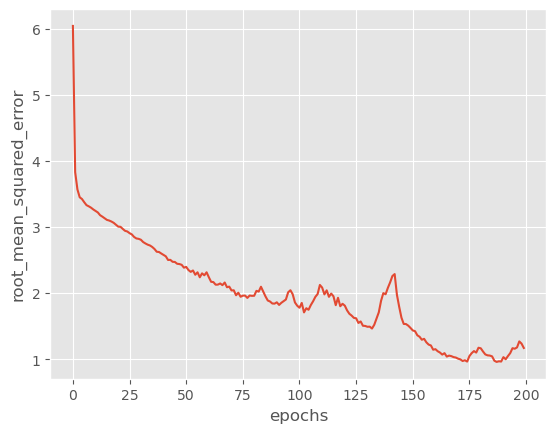

In [15]:
# Call the plot_history function we just created
plot_history(history_100_50, 'root_mean_squared_error')

## 7. Perform a prediction

In [16]:
y_train_predicted = model_100_50.predict(X_train)
y_val_predicted = model_100_50.predict(X_val)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


## 8. Measure performance

As we had the confusion matrix for classification, we can do a **scatter plot** for regression, showing true vs predicted value

In [17]:
# We define a function that we will reuse in this lesson
def plot_predictions(y_pred, y_true, title, ax):
    plt.style.use('ggplot')  # optional, that's only to define a visual style
    ax.scatter(y_pred, y_true, s=10, alpha=0.5)
    ax.axline((0,0),slope = 1, color = "black") # plot diagonal reference line
    ax.set_xlabel("predicted sunshine hours")
    ax.set_ylabel("true sunshine hours")
    ax.set_title(title)

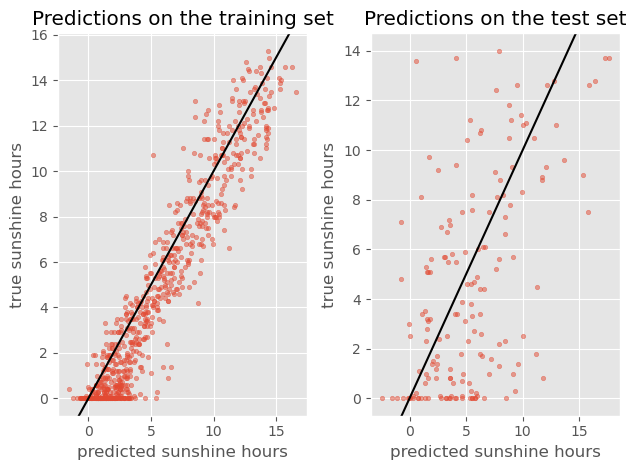

In [18]:
# Make a couple of plots, showing how our model performs in the data it used to learn (training set) and unseen data ()

fig, ax = plt.subplots(1,2)
plot_predictions(y_train_predicted, y_train, title='Predictions on the training set', ax = ax[0])
plot_predictions(y_val_predicted, y_val, title='Predictions on the test set', ax = ax[1])
plt.tight_layout()

As we defined a metric in our model, we can use `model.evaluate()` for the model to calculate the metric

In [19]:
## Fill in the blanks
# Calculate metrics
train_metrics = model_100_50.evaluate(X_train, y_train, return_dict=True)
val_metrics = model_100_50.evaluate(X_val, y_val, return_dict=True)

# Print for comparison
print(f'Train RMSE: {train_metrics['root_mean_squared_error']:.2f}, Validation RMSE: {val_metrics['root_mean_squared_error']:.2f}')

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4651 - root_mean_squared_error: 1.5701 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15.9467 - root_mean_squared_error: 3.9933 
Train RMSE: 1.57, Validation RMSE: 3.99


#### Questions

- Is our model good?
- How can we say if our model is good?
- What is our goal here: That the model can learn the data perfectly, or that it's able to generalize to unseen data?

### Setting a baseline

It's hard to say if your model is doing a good job if you don't have a baseline to compare.

In our case, some basic baseline comparisons are:
- Predict the same sunshine hours than the day before
- Predict the average of the last x days

In [20]:
# Create the baseline as the same sunshine hours than the day before
y_baseline_prediction = X_val['BASEL_sunshine']

# Calculate the RMSE for the baseline
rmse_baseline = root_mean_squared_error(y_val, y_baseline_prediction)
print('Baseline:', rmse_baseline)
# Compare to our model's RMSE
print('Neural network: ', val_metrics['root_mean_squared_error'])

Baseline: 4.247014733473557
Neural network:  3.9933290481567383


Here we have a good sign, our model has a lower error (RMSE), which means it predicts better than the baseline.

### Overfitting

When building a model, one thing we want to avoid is overfitting.

It happens when performance in our validation set is much worse than in the train set. Basically, our model is able to learn from the training data, but not able to generalize to unseen data.

To check for overfitting, let's add the `validation_data` argument to the `model.fit()` function, and see how performance evolves as we train our network more (increased epochs).

In [21]:
# Starting over for Keras not to continue training where it finished last time
model_100_50 = create_nn(input_shape=(X_data.shape[1],), 
                         n_neurons = [100,50])
compile_model(model_100_50)

# Adding our validation_data argument
history_100_50 = model_100_50.fit(X_train, y_train,
                    batch_size=32,
                    epochs=200,
                    validation_data=(X_val, y_val),
                    verbose = 1)

Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 20.5121 - root_mean_squared_error: 4.5290 - val_loss: 14.8430 - val_root_mean_squared_error: 3.8527
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12.7529 - root_mean_squared_error: 3.5711 - val_loss: 11.5805 - val_root_mean_squared_error: 3.4030
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.9020 - root_mean_squared_error: 3.4499 - val_loss: 11.4841 - val_root_mean_squared_error: 3.3888
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.5304 - root_mean_squared_error: 3.3956 - val_loss: 11.1623 - val_root_mean_squared_error: 3.3410
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11.2362 - root_mean_squared_error: 3.3520 - val_loss: 11.1847 - val_root_mean_squared_error: 3.3444
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11.0004 - root_mean_squared_error: 3.3167 - val_loss: 11.0727 - val_root_mean_squared_error: 3.3276
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

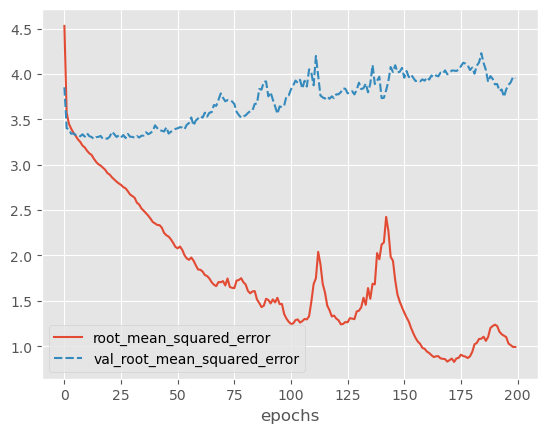

In [22]:
# Plotting the RMSE for training and validation data
plot_history(history_100_50, ['root_mean_squared_error', 'val_root_mean_squared_error'])

#### Question:
Is it a good sign that our validation RMSE increases while the training RMS decreases?

## 9. Refine the model

Try a different architecture by:
- reusing the create_nn function and changing the number of neurons
- changing the number of layers, or activation function in hidden layers
- adding a `BatchNormalization` layer ([documentation here](https://keras.io/api/layers/normalization_layers/batch_normalization/)) right after the input layer

Answer these questions:
- How does your new model compare to our baseline and our first model?
- How does it relate in terms of overfitting compared to our first model?

### Early Stopping:

A technique to avoid overfitting. Basically, tells the models to stop training when the validation loss hasn't improved in the last n epochs.

In [28]:
# Define architecture
model_50_50 = create_nn(input_shape=(X_data.shape[1],), 
                         n_neurons = [50,50])

# Compile with loss function and optimizer
compile_model(model_50_50)

# Setting early stopping parameters
earlystopper = EarlyStopping(monitor='val_loss', patience=10)


# Training
history_50_50 = model_50_50.fit(X_train, y_train,
                    batch_size=32,
                    epochs=200,
                    validation_data=(X_val, y_val),
                    verbose = 1,
                    callbacks=[earlystopper])

Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 18.5025 - root_mean_squared_error: 4.3015 - val_loss: 14.5252 - val_root_mean_squared_error: 3.8112
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13.9023 - root_mean_squared_error: 3.7286 - val_loss: 12.9212 - val_root_mean_squared_error: 3.5946
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13.2566 - root_mean_squared_error: 3.6410 - val_loss: 11.5669 - val_root_mean_squared_error: 3.4010
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12.9166 - root_mean_squared_error: 3.5940 - val_loss: 11.1659 - val_root_mean_squared_error: 3.3415
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12.3844 - root_mean_squared_error: 3.5192 - val_loss: 10.9145 - val_root_mean_squared_error: 3.3037
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11.9432 - root_mean_squared_error: 3.4559 - val_loss: 10.8773 - val_root_mean_squared_error: 3.2981
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/

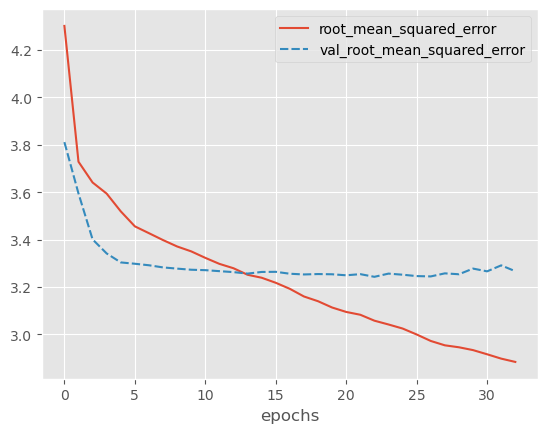

In [29]:
plot_history(history_50_50, ['root_mean_squared_error', 'val_root_mean_squared_error'])